# 06. Owner-Facing Exhibits

This notebook writes the exhibits that a nontechnical property owner can use to decide where risk is highest and how to fund security.

The briefing geography is **Northern Utah.** Ogden (Weber County), Layton (Davis County), and Logan (Cache County) are the places that cleared the population floor. The project plan names Northern Utah as the owner briefing case.

The central finding from notebook 04 is that poverty, ethnic heterogeneity, and residential instability all statistically significantly affect the property crime rate. Each coefficient tells an owner how much the expected crime rate rises when a community condition worsens by one unit. This notebook connects those coefficients to the three Northern Utah cities so an owner can see (1) where their cities sit on each risk driver, (2) which drivers are trending in a concerning direction, and (3) how to allocate security spending in response.

Authorization remains in the mix table at zero dollars. That is a finding about the scored property-crime index (burglary, larceny-theft, and motor vehicle theft) (Federal Bureau of Investigation, 2019).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

HERE = Path.cwd()
if (HERE / "data" / "processed" / "place_year_clean.csv").exists():
    ROOT = HERE
elif (HERE.parent / "data" / "processed" / "place_year_clean.csv").exists():
    ROOT = HERE.parent
else:
    raise FileNotFoundError("Run this notebook from the Capstone root or from scripts/.")

PROCESSED = ROOT / "data" / "processed"
FIGDIR = ROOT / "scripts" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

CLEAN = PROCESSED / "place_year_clean.csv"
COEF = PROCESSED / "ols_coefficients.csv"
VIF = PROCESSED / "vif.csv"
MIX = PROCESSED / "control_mix.csv"
EQUAL = PROCESSED / "lp_equal_share.csv"
CMP = PROCESSED / "lp_comparison.csv"
PRED = PROCESSED / "ridge_predictions.csv"
RESID = FIGDIR / "04_residual_vs_fitted.png"

NU_PLACES = ["Ogden city", "Layton city", "Logan city"]
NU_LABELS = {
    "Ogden city": "Ogden",
    "Layton city": "Layton",
    "Logan city": "Logan",
}
PRED_LABELS = {
    "poverty_rate": "Poverty rate (%)",
    "blau_heterogeneity": "Blau heterogeneity",
    "pct_moved_year": "Moved in last year (%)",
    "property_crime_rate": "Property-crime rate per 100,000",
}
CONTROLS = ["fortification", "surveillance", "alarm", "authorization"]
ROLE = {
    "fortification": "Prevent — delay",
    "surveillance": "Prevent — watch",
    "alarm": "React — notify",
    "authorization": "Access — theft",
}
SECURITY_SLICE_USD = 1_000_000

sns.set_theme(style="whitegrid", context="notebook")
print("ROOT", ROOT)

ROOT C:\Users\Owner\OneDrive\Capstone


## File Gate

Exhibits begin only when the cleaned table, the OLS coefficient and VIF files, the Ridge predictions, the linear-program mix, and the residual scatter are on disk.

In [2]:
required = [CLEAN, COEF, VIF, MIX, EQUAL, CMP, PRED, RESID]
missing = [p for p in required if not p.exists()]
print("missing", missing)
assert not missing, missing

df = pd.read_csv(CLEAN)
coef = pd.read_csv(COEF)
vif = pd.read_csv(VIF)
mix = pd.read_csv(MIX)
equal = pd.read_csv(EQUAL)
cmp = pd.read_csv(CMP)
pred = pd.read_csv(PRED)
print("clean", len(df), "mix rows", len(mix))

missing []
clean 2182 mix rows 12


## Sample Confirmation

The unit remains the place-year. Confirmation reprints the year split and the number of unique places so the briefing figures can be read against the same universe. It also names the three Northern Utah cities that remain after the population floor.

In [3]:
print("\nSAMPLE CONFIRMATION")
print(df.groupby("year").size())
print("place-years", len(df), "places", df["place"].nunique())
print("\nNorthern Utah in the cleaned table")
print(
    df.loc[df["place"].isin(NU_PLACES), ["place", "state_abbr"]]
    .drop_duplicates()
    .sort_values("place")
    .to_string(index=False)
)


SAMPLE CONFIRMATION
year
2022    706
2023    731
2024    745
dtype: int64
place-years 2182 places 729

Northern Utah in the cleaned table
      place state_abbr
Layton city         UT
 Logan city         UT
 Ogden city         UT


## Residual Scatter

D210 asks for a picture of the regression that a nontechnical owner can read. The residual-versus-fitted scatter (Larose & Larose, 2019) is shown below. A random cloud around the zero line would support linearity and constant variance. A fan at higher fitted rates is a limitation of the constant-variance condition.


RESIDUAL SCATTER


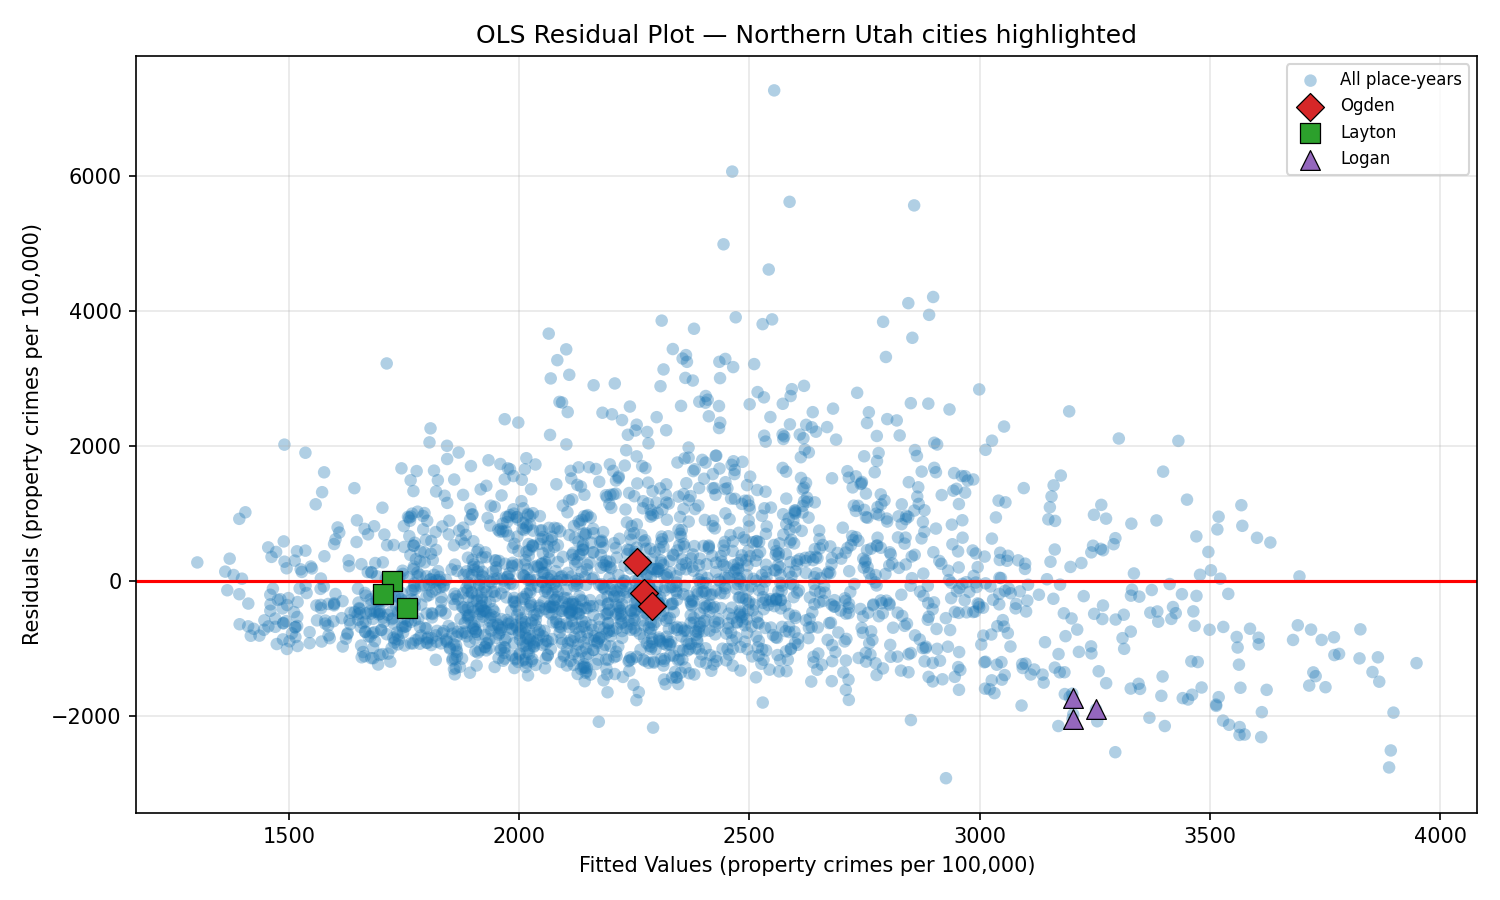

source C:\Users\Owner\OneDrive\Capstone\scripts\figures\04_residual_vs_fitted.png


In [4]:
print("\nRESIDUAL SCATTER")
display(Image(filename=str(RESID)))
print("source", RESID)

The residual scatter fans as fitted rates rise. That pattern matches the right-skewed property-crime rate and is a limitation of the constant-variance condition. Residuals also cluster because the table is a three-year panel of places. The OLS coefficients still decide H0.

## Hypothesis Coefficients and Variance Inflation

H0 was rejected at α = 0.05. The slopes in crimes per 100,000 and the Stage 2 variance-inflation factors are reprinted so the briefing can cite the quantitative benefit (James et al., 2013; Larose & Larose, 2019).

In [5]:
print("\nHYPOTHESIS COEFFICIENTS AND VARIANCE INFLATION")
print("OLS COEFFICIENTS (property crimes per 100,000)")
print(coef.to_string(index=False))
print("\nVIF (flag > 5)")
print(vif.to_string(index=False))


HYPOTHESIS COEFFICIENTS AND VARIANCE INFLATION
OLS COEFFICIENTS (property crimes per 100,000)
              term       Coef.   Std.Err.         t        P>|t|     [0.025      0.975]
             const  496.371144 118.035572  4.205267 2.713261e-05 264.897040  727.845249
      poverty_rate   59.978865   3.857559 15.548401 8.906319e-52  52.413986   67.543745
blau_heterogeneity 1139.905470 168.310409  6.772638 1.621254e-11 809.839707 1469.971233
    pct_moved_year   28.431477   4.645942  6.119636 1.109017e-09  19.320533   37.542420

VIF (flag > 5)
          Variable       VIF  flag_gt_5
             const 27.100860      False
      poverty_rate  1.157460      False
blau_heterogeneity  1.000944      False
    pct_moved_year  1.158471      False


We rejected the null hypothesis at α = 0.05. Holding the other two mediators constant, a one-percentage-point higher poverty rate is associated with about 60 additional property crimes per 100,000 residents; a one-percentage-point higher share of residents who moved in the last year is associated with about 28 additional crimes per 100,000; and a 0.10 higher Blau index is associated with about 114 additional crimes per 100,000 (Blau, 1977; Messner, 1986). Those slopes are the quantitative benefit the briefing cites.

Poverty and percent moved correlate moderately. Blau heterogeneity is nearly uncorrelated with the other two mediators. The predictor VIFs are 1.16, 1.00, and 1.16. None exceeds 5. The three locked mediators are independent enough for the OLS slopes to be read as separate associations.

## Northern Utah: What Is Actually Happening to Property Crime?

Before connecting the regression to Northern Utah, start with the recorded numbers. The table below shows both the raw offense count reported to the FBI and the rate per 100,000 residents. All three cities saw property crime **fall** between 2022 and 2024:

| City | Pop. (2024) | 2022 | 2023 | 2024 | Change |
|------|------------:|-----:|-----:|-----:|-------:|
| Ogden | 87,413 | 2,204 (2,541/100k) | 1,817 (2,089/100k) | 1,680 (1,922/100k) | −524 offenses (−25%) |
| Layton | 83,286 | 1,410 (1,725/100k) | 1,246 (1,510/100k) | 1,131 (1,358/100k) | −279 offenses (−21%) |
| Logan | 54,907 | 716 (1,345/100k) | 786 (1,458/100k) | 634 (1,155/100k) | −82 offenses (−11%) |

In concrete terms, Ogden went from 2,204 burglaries, larcenies, and motor-vehicle thefts in 2022 to 1,680 in 2024. Layton dropped from 1,410 to 1,131. Logan’s count is smaller in absolute terms (634–786 per year) because it is the smallest city (population ~55,000).

That is the good news. The question for a property owner is whether the decline will continue, and the answer depends on where the **underlying risk drivers** are heading. The regression found that each percentage point of poverty adds about 60 crimes per 100,000, each point of residential mobility adds about 28, and a 0.10 increase in the Blau index adds about 114. If those drivers are worsening even as the crime rate falls, the improvement may not last.


NORTHERN UTAH ON THE LOCKED PREDICTORS
 year   city  acs_population  property_crime_rate  poverty_rate  blau_heterogeneity  pct_moved_year       r_hat tier
 2022 Layton         81726.0          1725.277146           7.5            0.368313            12.6 1746.331814  low
 2023 Layton         82512.0          1510.083382           7.0            0.380249            12.5 1725.768765  low
 2024 Layton         83286.0          1357.971328           8.1            0.389106            11.6 1794.071901  low
 2022  Logan         53246.0          1344.701949          24.1            0.403994            29.9 3289.682903 high
 2023  Logan         53923.0          1457.634034          23.0            0.409989            30.2 3228.508294 high
 2024  Logan         54907.0          1154.679731          22.3            0.421603            31.2 3216.688293 high
 2022  Ogden         86754.0          2540.516864          12.1            0.517825            15.6 2320.980278  low
 2023  Ogden         869

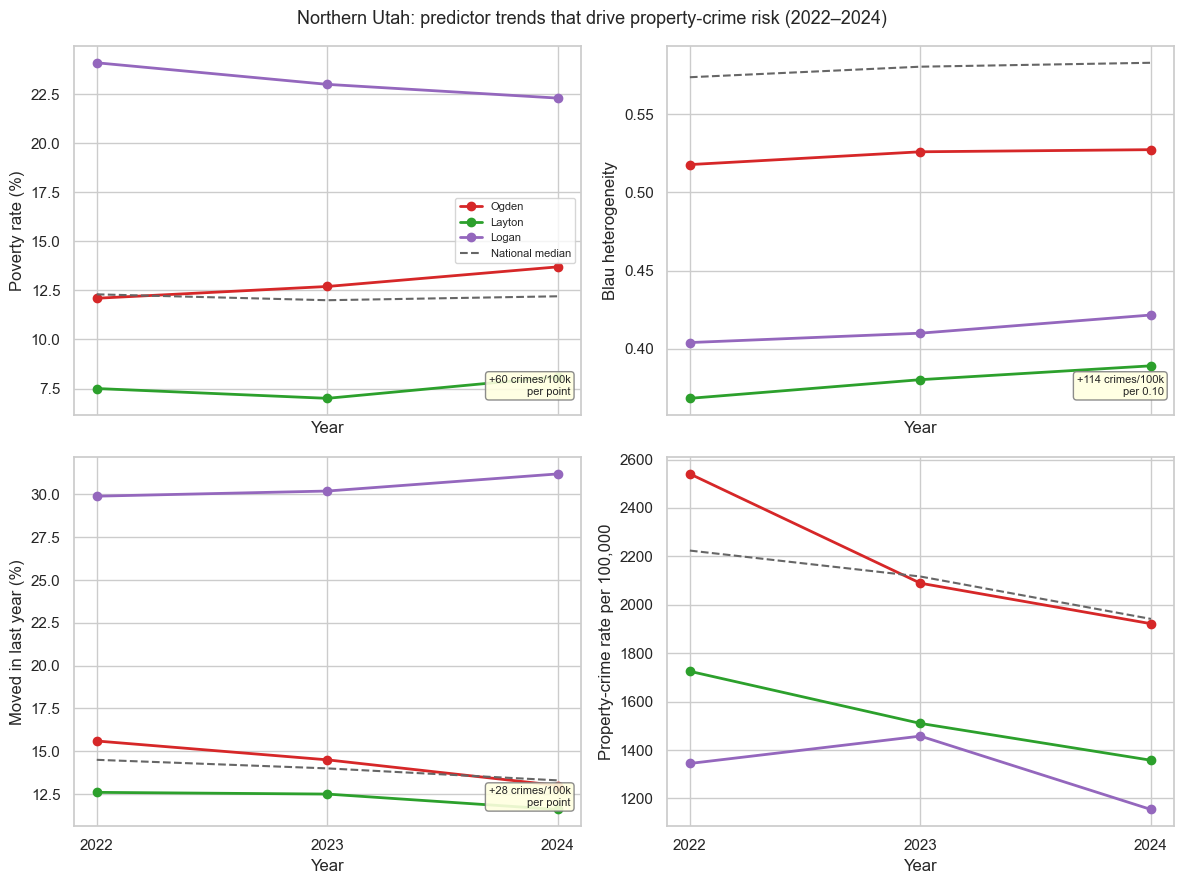

wrote C:\Users\Owner\OneDrive\Capstone\scripts\figures\06_nu_predictor_trends.png


In [6]:
nu = df[df["place"].isin(NU_PLACES)].copy()
nu["city"] = nu["place"].map(NU_LABELS)
nu = nu.merge(
    pred[["geoid", "year", "r_hat", "tier"]],
    on=["geoid", "year"],
    how="left",
)
assert set(nu["place"].unique()) == set(NU_PLACES)

nat = (
    df.groupby("year")[list(PRED_LABELS)]
    .median()
    .reset_index()
    .melt(id_vars="year", var_name="measure", value_name="national_median")
)

print("\nNORTHERN UTAH ON THE LOCKED PREDICTORS")
print(
    nu[
        [
            "year", "city", "acs_population", "property_crime_rate",
            "poverty_rate", "blau_heterogeneity", "pct_moved_year",
            "r_hat", "tier",
        ]
    ]
    .sort_values(["city", "year"])
    .to_string(index=False)
)

nu_path = PROCESSED / "nu_briefing.csv"
nu.to_csv(nu_path, index=False)
print("wrote", nu_path)

CITY_COLORS = {"Ogden": "#d62728", "Layton": "#2ca02c", "Logan": "#9467bd"}
COEFF_NOTE = {
    "poverty_rate": "+60 crimes/100k\nper point",
    "blau_heterogeneity": "+114 crimes/100k\nper 0.10",
    "pct_moved_year": "+28 crimes/100k\nper point",
    "property_crime_rate": "",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
for ax, col in zip(axes.ravel(), PRED_LABELS):
    for city in ["Ogden", "Layton", "Logan"]:
        cdata = nu[nu["city"] == city].sort_values("year")
        ax.plot(
            cdata["year"], cdata[col],
            marker="o", color=CITY_COLORS[city], linewidth=2,
            label=city,
        )
    med = nat.loc[nat["measure"] == col, ["year", "national_median"]]
    ax.plot(
        med["year"], med["national_median"],
        linestyle="--", color="0.4", linewidth=1.5,
        label="National median",
    )
    ax.set_ylabel(PRED_LABELS[col])
    ax.set_xlabel("Year")
    ax.set_xticks([2022, 2023, 2024])
    note = COEFF_NOTE.get(col, "")
    if note:
        ax.text(
            0.98, 0.05, note, transform=ax.transAxes,
            fontsize=8, ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray", alpha=0.9),
        )
axes[0, 0].legend(title="", loc="best", fontsize=8)
fig.suptitle(
    "Northern Utah: predictor trends that drive property-crime risk (2022\u20132024)",
    fontsize=13,
)
fig.tight_layout()
trend_path = FIGDIR / "06_nu_predictor_trends.png"
fig.savefig(trend_path, dpi=150)
plt.show()
print("wrote", trend_path)


### What the Trends Mean for Property Owners

**Ogden.** Reported property crimes dropped from 2,204 to 1,680 over three years — 524 fewer burglaries, larcenies, and motor-vehicle thefts. The rate fell 25%, from 2,541 to 1,922 per 100,000, dropping below the national median by 2024. That is a meaningful improvement. But the underlying conditions moved in opposite directions. Poverty climbed from 12.1% to 13.7%, crossing the national median. That 1.6-point increase, at the regression coefficient of ~60 crimes per 100,000 per point, translates to about 96 additional *expected* crimes per 100,000 — or roughly 84 more offenses per year in a city of 87,000. Residential mobility fell (15.6% → 13.0%), which offsets about 73 expected crimes per 100,000 (~64 offenses). Net: the two forces nearly cancel. The recorded count is improving, but the strongest predictor (poverty) is moving the wrong way. **Watch the poverty line.**

**Logan.** The city recorded 716 property crimes in 2022, 786 in 2023, and 634 in 2024 — the smallest raw numbers of the three because Logan’s population (~55,000) is about two-thirds of Ogden or Layton. The per-capita rate (1,155–1,458 per 100,000) is also the lowest in two of three years. On paper, Logan looks calm. But the predictors tell a different story. Poverty sits above 22%, roughly 10 points above the national median, and about 30% of residents moved in the last year, more than double Layton’s rate. The regression reads this as high risk: the poverty gap alone (Logan 22–24% vs. Layton 7–8%) implies ~900 more expected crimes per 100,000 than Layton — equivalent to about 500 additional offenses per year scaled to Logan’s population. Ridge scores Logan in the high tier in all three years. The low recorded count may reflect local factors the model does not capture (e.g., campus policing), but the structural conditions that drive property crime nationally are elevated. **An owner in Logan should not treat the low recorded count as a reason to underinvest in security.**

**Layton.** Reported property crimes fell from 1,410 to 1,131 — a 21% decline, 279 fewer offenses. The rate (1,358 per 100,000 in 2024) stayed consistently below the national median. Poverty stayed below 9%, mobility below 13%, Blau index around 0.38. All three predictors are below the national medians in every year. The regression confirms what the recorded count shows: Layton is the lowest-risk site. **An owner here can maintain baseline security spending,** but should re-check when new ACS estimates publish.

## Security Slice of Fixed-Asset Investment

The linear program in notebook 05 allocated a fixed planning budget of \(B = \$10{,}000{,}000\) across four CPTED families (Bradley et al., 1977; Cozens et al., 2005). The pot is a fixed comparison device. Asset value and risk set that slice (Kingdom Security, 2022). This notebook restates the solved mix as shares of **that slice**.

On the locked planning pot the solved mix is 50 percent fortification, 35 percent surveillance, and 15 percent alarm. Those percents apply to any security line taken from a PPE program. The notify share follows the alarm role: detection and call-out (Coupe & Kaur, 2005). The worked column uses a \$1 million security slice so a plant owner can read dollars without confusing the national pot with one site’s invoice.

**Authorization.** Electronic access control is mainly a theft and occupancy tool: who may enter, and who may walk inventory out. The scored target is burglary, larceny-theft, and motor vehicle theft (Federal Bureau of Investigation, 2019). Forced entry and lot theft are delay and watch problems first (Prenzler, 2009; Piza et al., 2019). Property damage (smash, arson, vandalism) is even less an authorization problem; arson is already out of the count. The solver therefore leaves authorization at zero for this index. An owner whose local problem is internal theft or badge control would put authorization back.


SECURITY SLICE OF FIXED-ASSET INVESTMENT
control_family            role  solved_share  equal_share  per_100_of_ppe_security  dollars_on_1M_slice
 fortification Prevent — delay          0.50         0.25                     50.0             500000.0
  surveillance Prevent — watch          0.35         0.25                     35.0             350000.0
         alarm  React — notify          0.15         0.25                     15.0             150000.0
 authorization  Access — theft          0.00         0.25                      0.0                  0.0
 budget_usd  exposure_total  solved_residual  equal_share_residual  residual_avoided solver_status
   10000000    9.225112e+06     9.207526e+06          9.215673e+06       8147.145884       Optimal
wrote C:\Users\Owner\OneDrive\Capstone\data\processed\lp_ppe_shares.csv


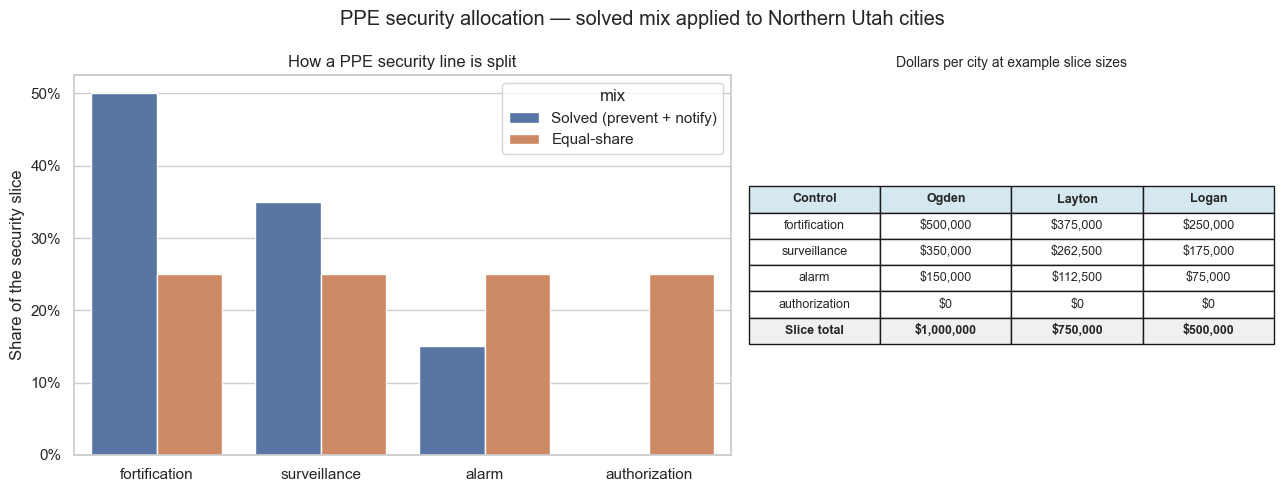

wrote C:\Users\Owner\OneDrive\Capstone\scripts\figures\06_ppe_security_shares.png


In [7]:
solved_k = mix.groupby("control_family", sort=False)["dollars"].sum().reindex(CONTROLS)
equal_k = equal.groupby("control_family", sort=False)["dollars"].sum().reindex(CONTROLS)
B = float(solved_k.sum())
shares = pd.DataFrame(
    {
        "control_family": CONTROLS,
        "role": [ROLE[k] for k in CONTROLS],
        "solved_share": (solved_k / B).to_numpy(),
        "equal_share": (equal_k / B).to_numpy(),
    }
)
shares["per_100_of_ppe_security"] = shares["solved_share"] * 100
shares["dollars_on_1M_slice"] = shares["solved_share"] * SECURITY_SLICE_USD
print("\nSECURITY SLICE OF FIXED-ASSET INVESTMENT")
print(shares.to_string(index=False))
print(cmp.to_string(index=False))

share_path = PROCESSED / "lp_ppe_shares.csv"
shares.to_csv(share_path, index=False)
print("wrote", share_path)

NU_SLICE = {"Ogden": 1_000_000, "Layton": 750_000, "Logan": 500_000}

fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                         gridspec_kw={"width_ratios": [5, 4]})

plot_df = shares.melt(
    id_vars=["control_family", "role"],
    value_vars=["solved_share", "equal_share"],
    var_name="mix",
    value_name="share",
)
plot_df["mix"] = plot_df["mix"].map(
    {"solved_share": "Solved (prevent + notify)", "equal_share": "Equal-share"}
)
sns.barplot(
    data=plot_df,
    x="control_family",
    y="share",
    hue="mix",
    ax=axes[0],
)
axes[0].set_ylabel("Share of the security slice")
axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(lambda x, _pos: f"{100 * x:.0f}%")
axes[0].set_title("How a PPE security line is split")

cols = ["Control"] + list(NU_SLICE.keys())
rows = []
for _, row in shares.iterrows():
    r = [row["control_family"]]
    for city, slc in NU_SLICE.items():
        r.append(f"${row['solved_share'] * slc:,.0f}")
    rows.append(r)
rows.append(["Slice total"] + [f"${s:,.0f}" for s in NU_SLICE.values()])

axes[1].axis("off")
tbl = axes[1].table(
    cellText=rows,
    colLabels=cols,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(fontweight="bold")
        cell.set_facecolor("#D5E8F0")
    if r == len(rows):
        cell.set_text_props(fontweight="bold")
        cell.set_facecolor("#F0F0F0")
axes[1].set_title("Dollars per city at example slice sizes", fontsize=10)

fig.suptitle("PPE security allocation — solved mix applied to Northern Utah cities")
fig.tight_layout()
mix_fig = FIGDIR / "06_ppe_security_shares.png"
fig.savefig(mix_fig, dpi=150)
plt.show()
print("wrote", mix_fig)


On each $100 of security capital taken from the fixed-asset program the solved mix puts $50 on fortification (fences, lighting, physical hardening), $35 on surveillance (cameras, monitoring), $15 on alarm (intrusion detection), and $0 on authorization (access control).

Why this order matters for the Northern Utah owner: the regression showed that the property crimes driven by poverty and residential instability — burglary and larceny — are overwhelmingly forced-entry and lot crimes. Those respond to **delay** (a burglar hits the fence) and **watch** (a camera deters or identifies). Authorization (badge readers, key cards) addresses credentialed-access problems, which are not what the scored property-crime index measures. Alarm is reactive — it notifies after a breach — so it gets the 15% floor but not the majority.

A site in Logan, where the risk drivers are elevated, needs this prevention-heavy mix funded at a higher absolute level than a site in Layton, where the same percentages apply to a smaller security slice.

## Ogden Walk-Through: Turning Trends into Dollars

Ogden is the briefing city because its predictor trends are moving — poverty is climbing, mobility is falling, and the net effect is uncertain. Ridge places Ogden in the low tier, but the poverty trajectory warrants attention. The percentage stack is applied to a $1 million security slice.

In [8]:
og = nu[(nu["city"] == "Ogden")].sort_values("year")
print("\nOGDEN WALK-THROUGH")
print(
    og[
        [
            "year",
            "acs_population",
            "property_crime_rate",
            "poverty_rate",
            "blau_heterogeneity",
            "pct_moved_year",
            "r_hat",
            "tier",
        ]
    ].to_string(index=False)
)
og24 = og[og["year"] == 2024].iloc[0]
nat24 = df[df["year"] == 2024]
print("\n2024 Ogden vs national median")
for col in PRED_LABELS:
    print(
        f"  {col}: Ogden {og24[col]:.3f}  national median {nat24[col].median():.3f}"
    )
print("\nIf Ogden funds a $1,000,000 security slice of PPE:")
for _, row in shares.iterrows():
    print(
        f"  {row['control_family']:15s}  {row['role']:16s}  ${row['dollars_on_1M_slice']:,.0f}"
    )


OGDEN WALK-THROUGH
 year  acs_population  property_crime_rate  poverty_rate  blau_heterogeneity  pct_moved_year       r_hat tier
 2022         86754.0          2540.516864          12.1            0.517825            15.6 2320.980278  low
 2023         86973.0          2089.154105          12.7            0.526008            14.5 2350.000560  low
 2024         87413.0          1921.910929          13.7            0.527365            13.0 2389.086955  low

2024 Ogden vs national median
  poverty_rate: Ogden 13.700  national median 12.200
  blau_heterogeneity: Ogden 0.527  national median 0.583
  pct_moved_year: Ogden 13.000  national median 13.300
  property_crime_rate: Ogden 1921.911  national median 1941.686

If Ogden funds a $1,000,000 security slice of PPE:
  fortification    Prevent — delay   $500,000
  surveillance     Prevent — watch   $350,000
  alarm            React — notify    $150,000
  authorization    Access — theft    $0


Ogden in 2024 is poorer than the national median (poverty 13.7 versus 12.2), slightly less mobile (13.0 versus 13.3), and less heterogeneous (Blau 0.53 versus 0.58). The recorded rate (1,922) sits near the national median and below the 2022 rate.

But the owner’s job is not just to read today’s numbers — it is to watch where the numbers are heading. Ogden’s poverty rate rose 1.6 points over three years. At the national coefficient of ~60 crimes per 100,000 per point, that trend adds about 96 expected crimes per 100,000 per year to the city’s risk profile. If poverty continues rising at that pace, the crime-rate improvement could stall or reverse within a few years.

**The recommended action** is to keep the PPE security line prevention-heavy (delay and watch), keep a 15% notify band, and leave authorization off that line unless the local problem shifts to credentialed theft. Re-assess when updated ACS estimates publish: if poverty climbs past 15%, increase the absolute dollar amount of the security slice even if the percentage mix stays at 50 / 35 / 15.

## Briefing Sequence

D210 asked for a presentation order that a nontechnical owner can follow. The sequence is:

1. **Introduction.** The analyst speaks to owners of plant, property, and equipment in large U.S. cities. The briefing case is Northern Utah: Ogden, Layton, and Logan — expanding cities where new investment is flowing.
2. **Problem and research question.** Do poverty, ethnic heterogeneity, and residential instability statistically significantly affect the property-crime rate at α = 0.05?
3. **Process.** Official FBI Table 8 is joined to ACS. OLS decides H0. VIF checks independence. Ridge scores feed one linear program that splits a security slice of PPE.
4. **Findings — what the numbers mean for your city.** H0 is rejected. Each point of poverty ≈ +60 crimes per 100,000. Each point of mobility ≈ +28. Each 0.10 Blau ≈ +114. Logan’s high-poverty, high-mobility profile puts it in the high Ridge tier. Ogden’s rising poverty is the trend to watch. Layton is calm.
5. **Limitations and what this model does not cover.** See below.
6. **Actions.** Fund delay and watch first (50% fortification, 35% surveillance). Keep a 15% alarm band. Leave authorization off the scored-crime line. Sites in high-predictor cities (Logan) need a larger absolute security slice than low-predictor cities (Layton).
7. **What to monitor.** Re-assess when new ACS estimates publish. Watch poverty rate — it is the strongest single predictor (r = 0.37) and the one rising in Ogden. If poverty crosses 15%, increase the total security budget.


## Limitations: What This Model Covers — and What It Does Not

The R² of 0.170 means the three social-disorganization predictors account for about **17% of the variation** in the property-crime rate. That is a statistically significant share — and an 8× improvement over the naïve shortcut of using foreign-born population share (R² = 0.021, coefficient *negative*). But it also means **83% of the variation comes from factors this model does not measure.** A property owner should treat these results as one validated piece of a larger risk picture, not the whole picture.

### What the model does address

- **The foreign-born misconception.** The EDA and the baseline regression together demonstrate that foreign-born population share is a poor predictor of property crime (R² ≈ 2%, and the direction is *negative*). This study replaces that shortcut with three theory-grounded community conditions that explain 8× more variance.
- **Relative site risk.** The three predictors reliably separate higher-risk from lower-risk cities on a common scale. An owner comparing Ogden, Layton, and Logan can see *which community conditions* differ and by how much.
- **Budget direction.** The LP translates the relative risk into a starting allocation across security control families, so spending is proportional to measured exposure rather than guesswork.

### What the model does not address

The remaining 83% of variance is not random noise — it reflects real forces that published research has identified but that fall outside this study’s scope:

| Factor | Theory / Source | Why it matters for property owners |
|--------|----------------|-----------------------------------|
| **Policing intensity and strategy** | Deterrence theory; Weisburd et al. (2016) | Patrol density, hot-spot policing, and clearance rates directly affect offender calculus. A city with strong directed patrols may record less crime than its community conditions predict. |
| **Routine activities / opportunity** | Cohen & Felson (1979) | Property crime requires a motivated offender, a suitable target, and the *absence* of a capable guardian — all at the same time and place. Land use, business hours, foot traffic, and lighting shape opportunity independently of poverty or mobility. |
| **Collective efficacy** | Sampson, Raudenbush, & Earls (1997); Lanfear (2022) | Neighborhoods where residents know and trust each other intervene informally against disorder. Collective efficacy mediates the effect of disadvantage on crime and is not captured by ACS demographics alone. |
| **Income inequality (Gini)** | Ramos (2019); Itskovich (2025) | The gap between rich and poor within a city may matter more than the poverty rate alone. High inequality can generate relative deprivation that motivates property offending even in cities with moderate average poverty. |
| **Built environment and land use** | CPTED (Cozens et al., 2005); Crime Pattern Theory (Brantingham & Brantingham, 1993) | Street layout, mixed-use zoning, vacant lots, commercial density, and transit access create or suppress crime opportunities at the micro level. |
| **Economic cycle and employment** | Cantor & Land (1985) | Unemployment and consumer-spending shifts affect both the motivation to offend and the volume of targets (e.g., more packages on porches during e-commerce booms). |
| **Reporting and measurement** | SEARCH (2024); Congressional Research Service (2025) | Only about one-third of property crimes are reported to police. Variation in reporting culture across cities introduces noise that no predictor can fully explain. |

### What this means for a Northern Utah property owner

This analysis answers a narrow but important question: *do the social-disorganization conditions matter, and by how much?* The answer is yes — they matter more than the foreign-born shortcut by a factor of eight, and each predictor has a quantified per-unit effect. But an owner making a site-level security decision should layer this analysis with:

1. **Local police data** — Ogden, Layton, and Logan PDs publish annual reports and crime maps that capture policing effects this model cannot.
2. **Site-specific CPTED audits** — The LP recommends *what kind* of controls to fund; a CPTED walk-through determines *where on the property* to place them.
3. **Insurance loss history** — The insurer’s loss runs for the specific address capture the dark figure of crime (unreported losses, claims below deductible) that FBI data miss.
4. **Updated ACS releases** — The predictors in this study are refreshed annually by the Census Bureau. Re-running the model on new estimates is the simplest way to track whether risk is rising or falling.

None of these layers invalidates the regression — they complement it. The 17% this model explains is the *community-condition* layer. The other layers fill different parts of the remaining 83%.

## Future Analyses

The following extensions would fill specific gaps identified above:

1. **Panel fixed-effects model.** Fitting city fixed effects to the existing three-year panel would isolate *within-city changes* in predictors from *between-city differences*, addressing the autocorrelation (Durbin–Watson = 0.64) in the current OLS. The data already exist in `place_year_clean.csv`.

2. **Routine-activities layer.** Adding land-use mix (e.g., commercial-to-residential ratio from Census NAICS data) and a guardianship proxy (e.g., law-enforcement employees per capita from FBI LEOKA tables) would test whether opportunity-theory variables explain incremental variance beyond social disorganization (Cohen & Felson, 1979).

3. **Collective-efficacy survey.** For the three Northern Utah cities specifically, a short resident survey measuring mutual trust and willingness to intervene (Sampson et al., 1997) would capture the informal-control mechanism that ACS demographics cannot proxy. This would help explain why Logan’s recorded crime is lower than its predictor profile predicts.

4. **Income-inequality (Gini) predictor.** The ACS publishes a Gini coefficient at the place level (table B19083). Adding it as a fourth predictor would test whether inequality explains variance beyond the poverty rate alone (Ramos, 2019).

5. **NIBRS incident-level disaggregation.** Using National Incident-Based Reporting System microdata — which include offense type, location type, and time of day — would allow the LP to differentiate between, for example, after-hours warehouse burglaries (fortification + alarm) and daytime retail larceny (surveillance). This would sharpen the security-mix recommendation from four broad families to site- and shift-specific controls.

6. **Spatial lag / spatial error models.** Property crime rates in neighboring cities are not independent. A spatial regression (Anselin, 1988) would account for cross-boundary spillover — relevant in Northern Utah, where Ogden, Layton, and Logan sit along the same I-15 corridor.

Each of these would add a piece to the 83% of variance this model leaves on the table. The current study’s contribution is to establish the community-condition baseline and to retire the foreign-born shortcut with a quantified comparison.

## Close

This notebook reused the residual scatter, reprinted the locked coefficients and VIFs, wrote the Northern Utah predictor series with coefficient-impact annotations, restated the linear program as shares of a PPE security slice, walked through Ogden on a $1 million slice, and placed the findings in context: the three social-disorganization predictors explain 17% of property-crime variance (8× better than the foreign-born shortcut), but 83% remains, and complementary analyses are recommended.

Figures: `scripts/figures/04_residual_vs_fitted.png` (reused), `scripts/figures/06_nu_predictor_trends.png`, `scripts/figures/06_ppe_security_shares.png`.

Tables: `data/processed/nu_briefing.csv`, `data/processed/lp_ppe_shares.csv`.

## References

Blau, P. M. (1977). *Inequality and heterogeneity: A primitive theory of social structure*. Free Press.

Bradley, S. P., Hax, A. C., & Magnanti, T. L. (1977). *Applied mathematical programming*. Addison-Wesley.

Cozens, P. M., Saville, G., & Hillier, D. (2005). Crime prevention through environmental design (CPTED): A review and modern bibliography. *Property Management, 23*(5), 328–356. https://doi.org/10.1108/02637470510631483

Coupe, T., & Kaur, S. (2005). The role of alarms and CCTV in detecting non-residential burglary. *Security Journal, 18*(2), 29–42. https://doi.org/10.1057/palgrave.sj.8340198

Federal Bureau of Investigation. (2019). *Property crime*. Uniform Crime Reporting Program. https://ucr.fbi.gov/crime-in-the-u.s/2019/crime-in-the-u.s.-2019/topic-pages/property-crime

Hoerl, A. E., & Kennard, R. W. (1970). Ridge regression: Biased estimation for nonorthogonal problems. *Technometrics, 12*(1), 55–67. https://doi.org/10.1080/00401706.1970.10488634

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An introduction to statistical learning*. Springer. https://www.statlearning.com/

Kingdom Security. (2022, March 8). *How to build a budget for physical security*. https://www.kingdom.co.uk/blog/how-to-build-a-budget-for-physical-security

Larose, C. D., & Larose, D. T. (2019). *Data science using Python and R*. Wiley.

Messner, S. F. (1986). Modernization, structural characteristics, and societal rates of crime: An application of Blau's macrosociological theory. *The Sociological Quarterly, 27*(1), 27–41. https://doi.org/10.1111/j.1533-8525.1986.tb00247.x

Piza, E. L., Welsh, B. C., Farrington, D. P., & Thomas, A. L. (2019). CCTV surveillance for crime prevention: A 40-year systematic review with meta-analysis. *Criminology & Public Policy, 18*(1), 135–159. https://doi.org/10.1111/1745-9133.12419

Prenzler, T. (2009). *Preventing burglary in commercial and institutional settings: A place management and partnerships approach*. Australian Research Council Centre of Excellence in Policing and Security.

Anselin, L. (1988). *Spatial econometrics: Methods and models.* Kluwer Academic Publishers.

Cantor, D., & Land, K. C. (1985). Unemployment and crime rates in the post–World War II United States: A theoretical and empirical analysis. *American Sociological Review, 50*(3), 317–332. https://doi.org/10.2307/2095542

Cohen, L. E., & Felson, M. (1979). Social change and crime rate trends: A routine activity approach. *American Sociological Review, 44*(4), 588–608. https://doi.org/10.2307/2094589

Itskovich, E. (2025). Economic inequality, relative deprivation, and crime. *Journal of Quantitative Criminology.* https://doi.org/10.1080/07418825.2024.2447155

Lanfear, C. C. (2022). Collective efficacy and the built environment. *Criminology, 60*(2), 370–396. https://doi.org/10.1111/1745-9125.12304

Ramos, R. G. (2019). Does income inequality explain the geography of residential burglary? *ISPRS International Journal of Geo-Information, 8*(10), 439. https://doi.org/10.3390/ijgi8100439

Sampson, R. J., Raudenbush, S. W., & Earls, F. (1997). Neighborhoods and violent crime: A multilevel study of collective efficacy. *Science, 277*(5328), 918–924. https://doi.org/10.1126/science.277.5328.918

Weisburd, D., Eck, J. E., Braga, A. A., Telep, C. W., Cave, B., Bowers, K., Bruinsma, G., Gill, C., Groff, E., Hibdon, J., Hinkle, J., Johnson, S., Lawton, B., Lum, C., Ratcliffe, J., Rengert, G., Taniguchi, T., & Yang, S.-M. (2016). Place matters: Criminology for the twenty-first century. *Cambridge University Press.*
